In [2]:
import ee
from tqdm import tqdm
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
import geemap
from skimage.transform import resize

# import seaborn and theme it
import seaborn as sns
sns.set_theme(style="ticks", palette="pastel", font_scale=1.5, rc={"figure.figsize": (10, 7), "lines.linewidth": 2})

/Users/su28355962/Documents/codes/migration-estimation/.venv/lib/python3.9/site-packages/google/oauth2/__init__.py:40: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/su28355962/Documents/codes/migration-estimation/.venv/lib/python3.9/site-packages/google/auth/__init__.py:54: FutureWarning: You are using a Python version 3.9 past its end of life. Google will update google-auth with critical bug fixes on a best-effort basis, but not with any other fixes or features. Please upgrade your Python version, and then update google-auth.
  warnings.warn(eol_message.format("3.9"), FutureWarning)
/Users/su28355962/Documents/codes/migration-estimation/.venv/lib/python3.9/site-packages/google/api_core/_python_version_support.py:

In [3]:
ee.Authenticate()
ee.Initialize(project="ee-miantsaandr")

EEException: Cannot authenticate: Invalid request.

In [3]:
folder_path = "../data/parquet/"

path_parquet_disasters = (
    folder_path + "gd_disasters.parquet"
)

gdf_disasters = gpd.read_parquet(path_parquet_disasters)

In [4]:
gdf_disasters.head()

,ISO3,geometry,type,Start date,End date,Total figures
0,AB9,POINT (28.46257 9.46809),Flood,2023-01-01,2023-04-30,1045
1,AB9,POINT (28.46257 9.46809),Flood,2024-08-01,2024-08-31,1650
2,AB9,POINT (28.46257 9.46809),Flood,2024-09-01,2024-10-16,990
3,AB9,POINT (28.46257 9.46809),Flood,2024-09-01,2024-10-16,11930
4,AB9,POINT (28.46257 9.46809),Mixed disasters,2023-01-01,2023-12-31,4409


In [5]:
path_parquet_idu = (
    folder_path + "gd_idu.parquet"
)

gdf_idu = gpd.read_parquet(path_parquet_idu)

In [6]:
gdf_idu.head()

,ISO3,geometry,type,Start date,End date,Total figures
0,UKR,POINT (35.69709 47.65396),None,2026-04-27,2026-04-27,1
1,UKR,POINT (34.41673 46.97067),None,2026-04-27,2026-04-27,3
2,UKR,POINT (35.81234 50.31326),None,2026-04-27,2026-04-27,3
3,UKR,POINT (37.00333 50.16151),None,2026-04-27,2026-04-27,3
4,UKR,POINT (33.49169 51.86466),None,2026-04-27,2026-04-27,3


In [8]:
def resize_image(img_arr, target_size):
    return resize(img_arr, target_size, anti_aliasing=False)

In [9]:
def scale_landsat(img):
    optical = img.select("SR_B.").multiply(0.0000275).add(-0.2)
    return img.addBands(optical, None, True)


def cloud_mask_landsat9(image):
    qa = image.select("QA_PIXEL")
    cloud_mask = qa.bitwiseAnd(1 << 3).eq(0).And(qa.bitwiseAnd(1 << 4).eq(0))
    return image.updateMask(cloud_mask)

def mask_viirs_clouds(image):
    cloud_mask = image.select("QF_Cloud_Mask")
    cloud_confidence = cloud_mask.rightShift(6).bitwiseAnd(3)
    clear_mask = cloud_confidence.lte(1)
    return image.updateMask(clear_mask)

def ensure_crs_alignment(gdf, target_crs="EPSG:4326"):
    """Ensure GeoDataFrame is in the target CRS (WGS84 by default for Earth Engine)"""
    if gdf.crs != target_crs:
        print(f"Converting CRS from {gdf.crs} to {target_crs}")
        gdf = gdf.to_crs(target_crs)
    return gdf

def create_matched_geometry(point, buffer_distance, target_crs="EPSG:4326"):
    """Create Earth Engine geometry with proper CRS handling"""
    # Ensure point is in WGS84 for Earth Engine
    if hasattr(point, "to_crs"):
        point_wgs84 = point.to_crs(target_crs)
        ee_point = ee.Geometry.Point([point_wgs84.geometry.x, point_wgs84.geometry.y])
    else:
        ee_point = ee.Geometry.Point([point.geometry.x, point.geometry.y])

    buffer_geom = ee_point.buffer(buffer_distance)
    bounds_rect = buffer_geom.bounds()

    return ee_point, buffer_geom, bounds_rect


In [10]:
def get_landsat9_rgb_median_numpy(
    point_index,
    gdf,
    buffer_distance=5000,
    start_or_end="Start date",
    scale=30,
    target_size=(330, 330),
    target_crs="EPSG:4326",
):
    gdf_aligned = ensure_crs_alignment(gdf, target_crs)

    point = gdf_aligned.iloc[point_index]
    ee_point, buffer_geom, bounds_rect = create_matched_geometry(point, buffer_distance)

    # start and end dates (30 around the event date)
    start_date = point['Start date']
    end_date = point['End date']
    if isinstance(start_date, str) or isinstance(end_date, str):
        start_date = pd.to_datetime(start_date)
        end_date = pd.to_datetime(end_date)
    date = start_date + (end_date - start_date) / 2  # Use midpoint for the date
    date_start = (date - pd.Timedelta(days=90)).strftime("%Y-%m-%d")
    date_end = (date + pd.Timedelta(days=90)).strftime("%Y-%m-%d")

    collection = (
        ee.ImageCollection("LANDSAT/LC09/C02/T1_L2")
        .filterDate(date_start, date_end)
        .filterBounds(bounds_rect)
        .filter(ee.Filter.lt("CLOUD_COVER", 60))
        .map(cloud_mask_landsat9)
        .map(scale_landsat)
    )

    collection_size = collection.size().getInfo()
    if collection_size == 0:
        print(
            f"No Landsat images found for point {point_index} between {date_start} and {date_end}"
        )
        return None, None

    composite = collection.median().clip(bounds_rect)
    rgb = composite.select(["SR_B4", "SR_B3", "SR_B2"])
    date_str = f"{date_start}_to_{date_end}"

    try:
        np_image = geemap.ee_to_numpy(
            rgb, region=bounds_rect, scale=scale
        )

        if np_image.ndim != 3:
            print(
                f"Unexpected image dimensions for point {point_index}: {np_image.shape}"
            )
            return None, None

        # Resize image
        resized = resize_image(np_image, target_size=target_size)

        return resized, date_str

    except Exception as e:
        print(f"Error processing Landsat data for point {point_index}: {str(e)}")
        return None, None

Resized image shape: (330, 330, 3)
Date label: 2024-03-20_to_2024-09-16


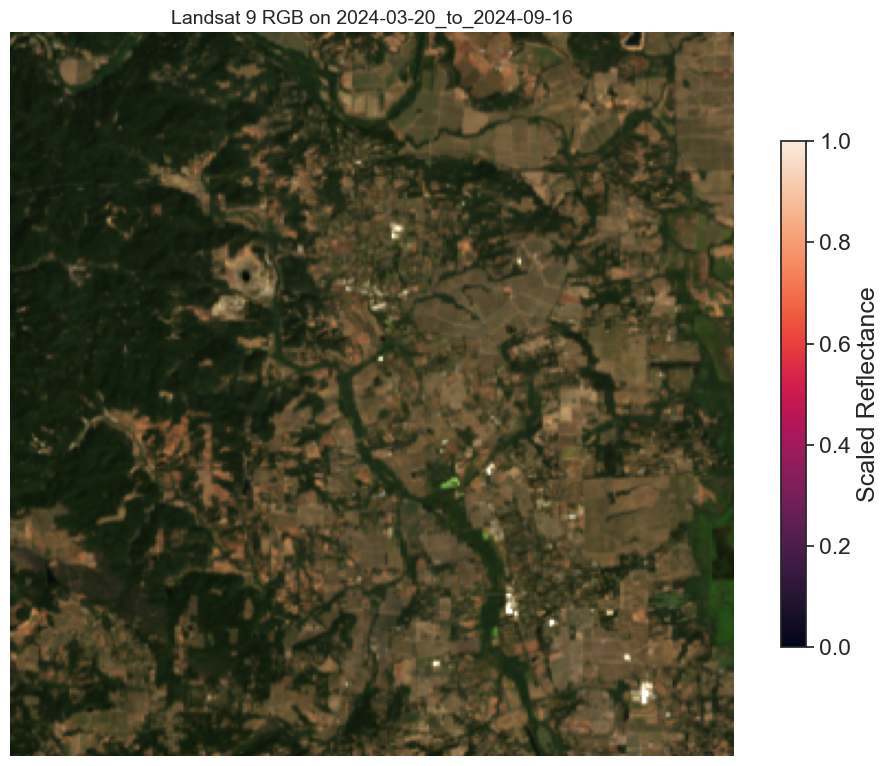

In [11]:
# test get landsat9_rgb_median_numpy
test_index = np.random.randint(0, len(gdf_disasters))
resized_img, date_label = get_landsat9_rgb_median_numpy(
    test_index, gdf_disasters, scale=30
)
# Plotting the resized image
print(f"Resized image shape: {resized_img.shape}")
print(f"Date label: {date_label}")

# Create figure
plt.figure(figsize=(10, 8))

# Enhance the RGB visualization with contrast stretching
# Landsat typically needs enhancement for better visualization
rgb_enhanced = np.copy(resized_img)
# Apply contrast stretching - multiply by factor to enhance visibility
# but keep within valid range [0,1]
rgb_enhanced = np.clip(rgb_enhanced * 3.5, 0, 1)  

# Display the image with enhanced colors
plt.imshow(rgb_enhanced)
plt.title(f"Landsat 9 RGB on {date_label}", fontsize=14)
plt.axis("off")

# Add colorbar to show scale
plt.colorbar(label="Scaled Reflectance", shrink=0.7)
plt.tight_layout()
plt.show()

In [12]:
def get_viirs_nightlight_median_numpy(
    point_index,
    gdf,
    buffer_distance=5000,
    start_or_end="Start date",
    scale=500,
    target_size=(20, 20),
    target_crs="EPSG:4326",
):

    # Ensure CRS alignment
    gdf_aligned = ensure_crs_alignment(gdf, target_crs)

    # Extract point and dates
    point = gdf_aligned.iloc[point_index]
    ee_point, buffer_geom, bounds_rect = create_matched_geometry(point, buffer_distance)

    date = point[start_or_end]
    if isinstance(date, str):
        date = pd.to_datetime(date)

    # two weeks around the event date
    date_start = (date - pd.Timedelta(days=7)).strftime("%Y-%m-%d")
    date_end = (date + pd.Timedelta(days=7)).strftime("%Y-%m-%d")

    # Image collection: filtered, cloud-masked
    collection = (
        ee.ImageCollection("NASA/VIIRS/002/VNP46A2")
        .filterDate(date_start, date_end)
        .filterBounds(bounds_rect)
        .select("Gap_Filled_DNB_BRDF_Corrected_NTL", "QF_Cloud_Mask", "Snow_Flag")
        .map(mask_viirs_clouds)
    )

    # Check if collection has images
    collection_size = collection.size().getInfo()
    if collection_size == 0:
        print(
            f"No VIIRS images found for point {point_index} between {date_start} and {date_end}"
        )
        return None, None

    # Median composite
    composite = collection.median().clip(bounds_rect)
    date_str = f"{date_start}_to_{date_end}"

    try:
        # Convert to NumPy array
        np_image = geemap.ee_to_numpy(
            composite.select("Gap_Filled_DNB_BRDF_Corrected_NTL"),
            region=bounds_rect,
            scale=scale,
        )

        # Handle potential 3D array
        if np_image.ndim == 3 and np_image.shape[-1] == 1:
            np_image = np_image[:, :, 0]

        # Resize image
        resized = resize_image(np_image, target_size=target_size)

        return resized, date_str

    except Exception as e:
        print(f"Error processing VIIRS data for point {point_index}: {str(e)}")
        return None, None

Resized VIIRS image shape: (20, 20)
Date label: 2024-08-13_to_2024-08-27


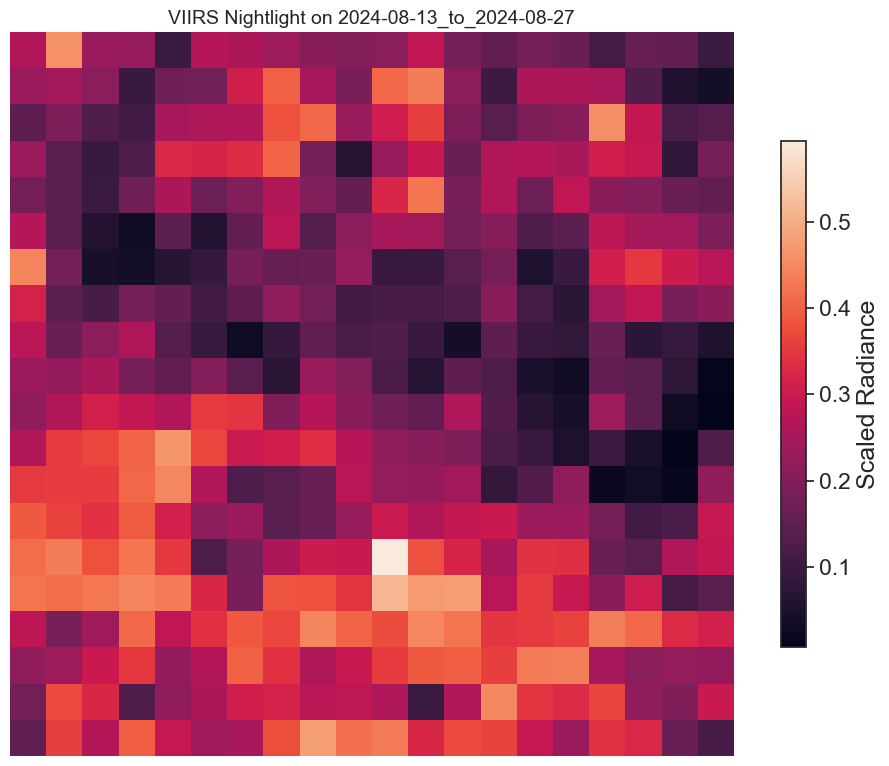

In [13]:
# plot viirs nightlight
# test_index = np.random.randint(0, len(gdf_flood))
test_index = 40
resized_img_viirs, date_label_viirs = get_viirs_nightlight_median_numpy(
    test_index, gdf_disasters, buffer_distance=5000, scale=500, target_size=(20, 20)
)
# Plotting the resized image
print(f"Resized VIIRS image shape: {resized_img_viirs.shape}")
print(f"Date label: {date_label_viirs}")
# Create figure
plt.figure(figsize=(10, 8))
# Enhance the nightlight visualization with contrast stretching
# VIIRS typically needs enhancement for better visualization
viirs_enhanced = np.copy(resized_img_viirs)
# Display the image with enhanced colors
plt.imshow(viirs_enhanced)
plt.title(f"VIIRS Nightlight on {date_label_viirs}", fontsize=14)
plt.axis("off")
# Add colorbar to show scale
plt.colorbar(label="Scaled Radiance", shrink=0.7)
plt.tight_layout()
plt.show()

In [14]:
def collect_unified_data(
    point_indices,
    gdf,
    buffer_distance=5000,
    start_or_end="Start date",
    viirs_scale=500,
    landsat_scale=30,
    # target_size=(330, 330),
    target_crs="EPSG:4326",
):

    results = {}

    for idx in point_indices:

        # Get nighttime lights data for start and end dates
        viirs_data_start = get_viirs_nightlight_median_numpy(
            idx,
            gdf,
            buffer_distance,
            "Start date",
            viirs_scale,
            (20, 20),
            target_crs,
        )

        viirs_data_end = get_viirs_nightlight_median_numpy(
            idx,
            gdf,
            buffer_distance,
            "End date",
            viirs_scale,
            (20, 20),
            target_crs,
        )

        # Get RGB data
        rgb_data = get_landsat9_rgb_median_numpy(
            idx,
            gdf,
            buffer_distance,
            start_or_end,
            landsat_scale,
            (330, 330),
            target_crs,
        )

        results[idx] = {
            "viirs_start": viirs_data_start[0],
            "viirs_end": viirs_data_end[0],
            "rgb": rgb_data[0],
            "figures": gdf.iloc[idx]["Total figures"],
            'iso3': gdf.iloc[idx]["ISO3"],
            'type': gdf.iloc[idx]["type"],
        }

    return results

- Data collect
    - parquet doesn't work because it doesn't save multi arrays
    

In [15]:
# collect some point
num = 5
point_indices = range(num)
collected_data = collect_unified_data(
    point_indices,
    gdf_disasters,
    buffer_distance=5000,
    start_or_end="Start date",
    viirs_scale=500,
    landsat_scale=30,
    # target_size=(330, 330),
    target_crs="EPSG:4326",
)

# view in dataframe
df_collected = pd.DataFrame.from_dict(
    collected_data, orient="index", columns=["viirs_start", "viirs_end", "rgb", "figures", "iso3", "type"]
)
# Display the first few rows of the DataFrame
df_collected

,viirs_start,viirs_end,rgb,figures,iso3,type
0,"[[0.01515171460923739, 0.11385649827774615, 0....","[[0.5087687080912292, 0.5022928973659874, 0.54...","[[[0.06273093181818183, 0.08196383333333333, 0...",1045,AB9,Flood
1,"[[0.16981798256747424, 0.178442805306986, 0.25...","[[0.3521034189499914, 0.3598535253852606, 0.41...","[[[0.030082644570707064, 0.03603906502525252, ...",1650,AB9,Flood
2,"[[0.3521034189499914, 0.3598535253852606, 0.41...","[[0.09947191144048702, 0.1543540622061119, 0.1...","[[[0.03676903535353535, 0.04008092045454545, 0...",990,AB9,Flood
3,"[[0.3521034189499914, 0.3598535253852606, 0.41...","[[0.09947191144048702, 0.1543540622061119, 0.1...","[[[0.03676903535353535, 0.04008092045454545, 0...",11930,AB9,Flood
4,"[[0.01515171460923739, 0.11385649827774615, 0....","[[0.041661641508108, 0.027608625961584036, 0.0...","[[[0.08283459911616164, 0.0832751452020202, 0....",4409,AB9,Mixed disasters


In [16]:
# shape of the things in the dataframe
print(f"Shape of VIIRS Start: {df_collected['viirs_start'].iloc[0].shape}")
print(f"Shape of VIIRS End: {df_collected['viirs_end'].iloc[0].shape}")
print(f"Shape of RGB: {df_collected['rgb'].iloc[0].shape}")
print(f"Figures: {df_collected['figures'].iloc[0]}")
print(f"ISO3: {df_collected['iso3'].iloc[0]}")
print(f"Type: {df_collected['type'].iloc[0]}")

Shape of VIIRS Start: (20, 20)
Shape of VIIRS End: (20, 20)
Shape of RGB: (330, 330, 3)
Figures: 1045
ISO3: AB9
Type: Flood


In [17]:
def plot_collected_data(data_row, index, rgb_enhance_factor=3.5):
    fig, axs = plt.subplots(1, 3, figsize=(15, 5))

    # Plot VIIRS Nightlight Start
    axs[0].imshow(data_row["viirs_start"], cmap="gray")
    axs[0].set_title(f"VIIRS Nightlight Start (Index {index})")
    axs[0].axis("off")

    # Plot VIIRS Nightlight End
    axs[1].imshow(data_row["viirs_end"], cmap="gray")
    axs[1].set_title(f"VIIRS Nightlight End (Index {index})")
    axs[1].axis("off")

    # Enhance RGB image
    rgb = np.copy(data_row["rgb"])
    rgb_enhanced = np.clip(rgb * rgb_enhance_factor, 0, 1)

    # Plot RGB Image
    axs[2].imshow(rgb_enhanced)
    axs[2].set_title(f"RGB Image (Index {index})")
    axs[2].axis("off")

    # Main Title with ISO3
    fig.suptitle(
        f"ISO3: {data_row['iso3']} — Total Figures: {data_row['figures']}", fontsize=16
    )

    plt.tight_layout()
    plt.show()


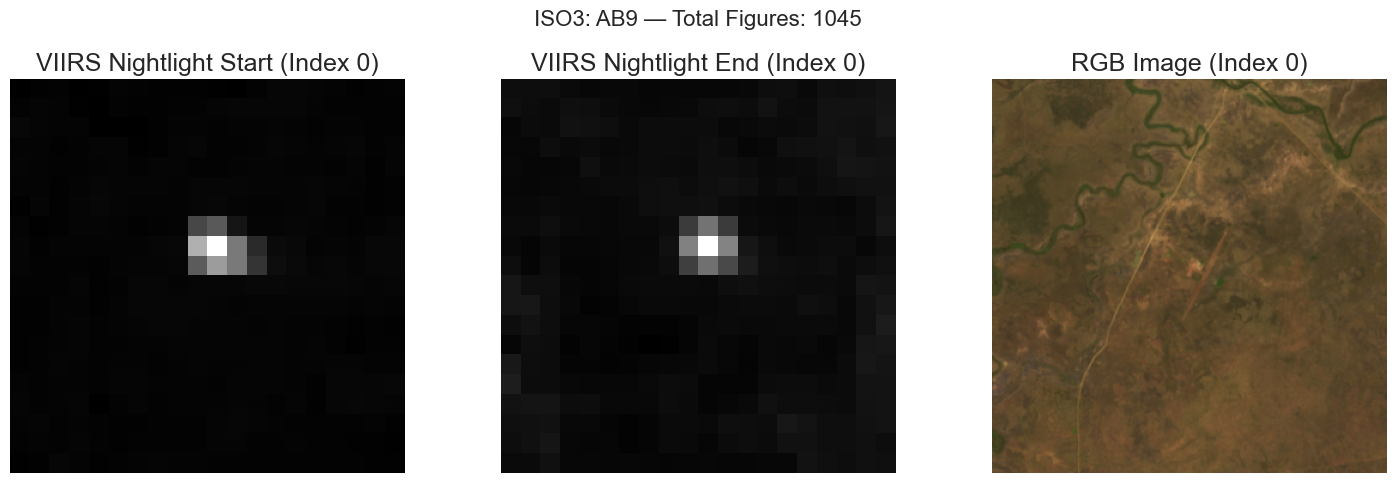

In [18]:
# Plot the random example from the collected data
random_index = np.random.choice(df_collected.index)
plot_collected_data(df_collected.loc[random_index], random_index)

In [19]:
import h5py
import numpy as np


def batched(iterable, n):
    """Yield successive n-sized chunks from iterable."""
    for i in range(0, len(iterable), n):
        yield iterable[i : i + n]

In [20]:
# read and put in dataframe
def read_hdf5_to_dataframe(h5_path="unified_data.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]

    # Decode bytes to strings
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame
    df = pd.DataFrame({
        "index": indices,
        "viirs_start": list(viirs_start),
        "viirs_end": list(viirs_end),
        "rgb": list(rgb),
        "figures": figures,
        "iso3": iso3_decoded,
        "type": types_decoded,
    })

    return df

- concurent future

In [21]:
import numpy as np
from concurrent.futures import ThreadPoolExecutor, as_completed


def safe_collect(batch, gdf):
    try:
        return batch, collect_unified_data(batch, gdf)
    except Exception as e:
        print(f"Error in batch {batch}: {e}")
        return batch, {}


def write_hdf5_batches_parallel(
    point_indices, gdf, h5_path="output_parallel.h5", batch_size=32, max_workers=8
):
    with h5py.File(h5_path, "w") as f:
        # Create resizable datasets with float RGB
        viirs_start_ds = f.create_dataset(
            "viirs_start",
            shape=(0, 20, 20),
            maxshape=(None, 20, 20),
            dtype="float32",
            chunks=True,
        )
        viirs_end_ds = f.create_dataset(
            "viirs_end",
            shape=(0, 20, 20),
            maxshape=(None, 20, 20),
            dtype="float32",
            chunks=True,
        )
        rgb_ds = f.create_dataset(
            "rgb",
            shape=(0, 330, 330, 3),
            maxshape=(None, 330, 330, 3),
            dtype="float32",
            chunks=True,
        )
        figures_ds = f.create_dataset(
            "figures", shape=(0,), maxshape=(None,), dtype="float32", chunks=True
        )
        indices_ds = f.create_dataset(
            "indices", shape=(0,), maxshape=(None,), dtype="int32", chunks=True
        )

        iso3_dtype = h5py.string_dtype(encoding='utf-8', length=3)
        iso3_ds = f.create_dataset(
            "iso3", shape=(0,), maxshape=(None,), dtype=iso3_dtype, chunks=True
        )

        type_dtype = h5py.string_dtype(encoding='utf-8', length=20)
        type_ds = f.create_dataset(
            "type", shape=(0,), maxshape=(None,), dtype=type_dtype, chunks=True
        )

        current_idx = 0
        futures = []
        batches = list(batched(point_indices, batch_size))

        with ThreadPoolExecutor(max_workers=max_workers) as executor:
            for batch in batches:
                futures.append(executor.submit(safe_collect, batch, gdf))

            for future in tqdm(
                as_completed(futures), total=len(futures), desc="Processing"
            ):
                batch, data = future.result()

                valid_entries = [
                    (idx, entry)
                    for idx, entry in data.items()
                    if all(
                        entry.get(key) is not None
                        for key in ["viirs_start", "viirs_end", "rgb", "figures", "iso3", "type"]
                    )
                ]

                if not valid_entries:
                    continue

                indices, valid_data = zip(*valid_entries)

                viirs_start = np.stack([entry["viirs_start"] for entry in valid_data])
                viirs_end = np.stack([entry["viirs_end"] for entry in valid_data])
                rgb = np.stack(
                    [entry["rgb"] for entry in valid_data]
                )  # float32 expected
                figures = np.array(
                    [entry["figures"] for entry in valid_data], dtype="float32"
                )
                idx_array = np.array(indices, dtype="int32")
                iso3_array = np.array([entry["iso3"] for entry in valid_data], dtype=iso3_dtype)
                type_array = np.array([entry["type"] for entry in valid_data], dtype=type_dtype)

                new_size = current_idx + len(valid_data)

                # Resize HDF5 datasets
                viirs_start_ds.resize(new_size, axis=0)
                viirs_end_ds.resize(new_size, axis=0)
                rgb_ds.resize(new_size, axis=0)
                figures_ds.resize(new_size, axis=0)
                indices_ds.resize(new_size, axis=0)
                iso3_ds.resize(new_size, axis=0)
                type_ds.resize(new_size, axis=0)

                # Write batch
                viirs_start_ds[current_idx:new_size] = viirs_start
                viirs_end_ds[current_idx:new_size] = viirs_end
                rgb_ds[current_idx:new_size] = rgb
                figures_ds[current_idx:new_size] = figures
                indices_ds[current_idx:new_size] = idx_array
                iso3_ds[current_idx:new_size] = iso3_array
                type_ds[current_idx:new_size] = type_array

                current_idx = new_size


In [22]:
gdf_disasters

,ISO3,geometry,type,Start date,End date,Total figures
0,AB9,POINT (28.46257 9.46809),Flood,2023-01-01,2023-04-30,1045
1,AB9,POINT (28.46257 9.46809),Flood,2024-08-01,2024-08-31,1650
2,AB9,POINT (28.46257 9.46809),Flood,2024-09-01,2024-10-16,990
3,AB9,POINT (28.46257 9.46809),Flood,2024-09-01,2024-10-16,11930
4,AB9,POINT (28.46257 9.46809),Mixed disasters,2023-01-01,2023-12-31,4409
...,...,...,...,...,...,...
13225,ZWE,POINT (32.67641 -18.58712),Storm,2024-03-13,2024-03-14,322
13226,ZWE,POINT (29.94154 -21.81297),Storm,2024-10-23,2024-10-23,25
13227,ZWE,POINT (28.46292 -20.97013),Storm,2024-11-03,2024-11-03,8
13228,ZWE,POINT (29.14799 -18.99393),Storm,2024-11-11,2024-11-17,40


- Code used to collect dissaster images

In [32]:
point_indices = list(range(len(gdf_disasters)))  # Use indices of gdf_disasters
# ten only
# point_indices = list(range(5)) 

write_hdf5_batches_parallel(
    point_indices=point_indices,
    gdf=gdf_disasters, # Use gdf_disasters for disaster data
    h5_path="disaster1.h5", # output file name
    batch_size=32,
)

Processing:   9%|▉         | 39/414 [15:38<2:08:33, 20.57s/it] 

No Landsat images found for point 1417 between 2022-10-18 and 2023-04-16


Processing:  10%|▉         | 40/414 [15:51<1:53:45, 18.25s/it]

No Landsat images found for point 1430 between 2022-10-18 and 2023-04-16


Processing:  15%|█▌        | 64/414 [24:33<1:07:42, 11.61s/it]

...

Processing:  91%|█████████ | 375/414 [2:42:07<21:47, 33.52s/it]

No Landsat images found for point 12111 between 2020-07-10 and 2021-01-06


Processing:  94%|█████████▍| 390/414 [2:47:50<08:39, 21.66s/it]

No Landsat images found for point 12648 between 2024-08-07 and 2025-02-03


Processing: 100%|██████████| 414/414 [3:37:28<00:00, 31.52s/it]   


In [33]:
df_unified_parallel = read_hdf5_to_dataframe(h5_path="disaster1.h5")

In [25]:
df_unified_parallel.head()

,index,viirs_start,viirs_end,rgb,figures,iso3,type
0,0,"[[0.015151715, 0.1138565, 0.14036517, 0.034680...","[[0.50876874, 0.5022929, 0.5414871, 0.42626747...","[[[0.06273093, 0.08196383, 0.036805302], [0.06...",1045.0,AB9,Flood
1,1,"[[0.16981798, 0.1784428, 0.25535116, 0.3351064...","[[0.3521034, 0.35985354, 0.41587752, 0.2753699...","[[[0.030082645, 0.036039066, 0.01613449], [0.0...",1650.0,AB9,Flood
2,2,"[[0.3521034, 0.35985354, 0.41587752, 0.2753699...","[[0.09947191, 0.15435407, 0.14794993, 0.009161...","[[[0.036769036, 0.04008092, 0.018147314], [0.0...",990.0,AB9,Flood
3,3,"[[0.3521034, 0.35985354, 0.41587752, 0.2753699...","[[0.09947191, 0.15435407, 0.14794993, 0.009161...","[[[0.036769036, 0.04008092, 0.018147314], [0.0...",11930.0,AB9,Flood
4,4,"[[0.015151715, 0.1138565, 0.14036517, 0.034680...","[[0.041661642, 0.027608626, 0.016215635, 0.052...","[[[0.0828346, 0.08327515, 0.042758837], [0.076...",4409.0,AB9,Mixed disasters


In [34]:
len(df_unified_parallel)

13180

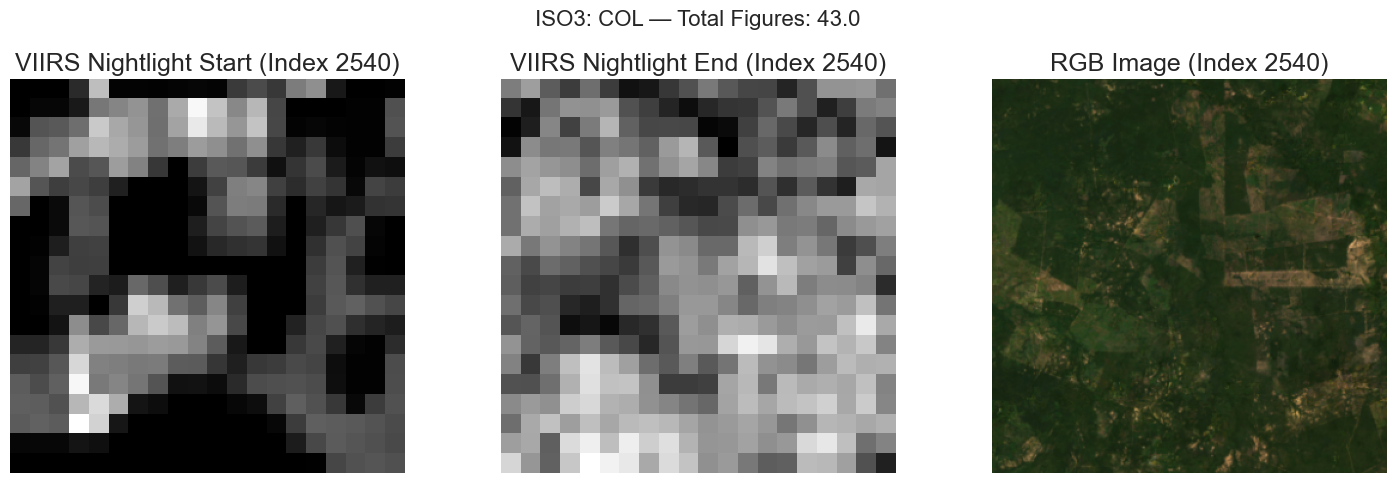

In [45]:
# plot a random example from the parallel dataframe
random_index = np.random.choice(df_unified_parallel.index)

# plot the random example from df_unified_parallel
plot_collected_data(df_unified_parallel.loc[random_index], random_index)

In [46]:
# modify so indices is the index of the dataframe
def read_hdf5_to_dataframe_with_index(h5_path="unified_parallel.h5"):
    with h5py.File(h5_path, "r") as f:
        viirs_start = f["viirs_start"][:]
        viirs_end = f["viirs_end"][:]
        rgb = f["rgb"][:]
        figures = f["figures"][:]
        indices = f["indices"][:]
        iso3 = f["iso3"][:]
        types = f["type"][:]
    
    # Decode bytes to strings for iso3
    iso3_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in iso3]
    types_decoded = [x.decode("utf-8") if isinstance(x, bytes) else x for x in types]

    # Create a DataFrame with indices as the index
    df = pd.DataFrame({
        "viirs_start": list(viirs_start),
        "viirs_end": list(viirs_end),
        "rgb": list(rgb),
        "figures": figures,
        "iso3": iso3_decoded,
        "type": types_decoded,
    }, index=indices)

    df.sort_index(inplace=True)  # Ensure indices are sorted

    return df

# Read the HDF5 file into a DataFrame with indices
df_unified_with_index = read_hdf5_to_dataframe_with_index(h5_path="disaster1.h5")

In [47]:
df_unified_with_index.sort_index(inplace=True)

In [48]:
df_unified_with_index

,viirs_start,viirs_end,rgb,figures,iso3,type
0,"[[0.015151715, 0.1138565, 0.14036517, 0.034680...","[[0.50876874, 0.5022929, 0.5414871, 0.42626747...","[[[0.06273093, 0.08196383, 0.036805302], [0.06...",1045.0,AB9,Flood
1,"[[0.16981798, 0.1784428, 0.25535116, 0.3351064...","[[0.3521034, 0.35985354, 0.41587752, 0.2753699...","[[[0.030082645, 0.036039066, 0.01613449], [0.0...",1650.0,AB9,Flood
2,"[[0.3521034, 0.35985354, 0.41587752, 0.2753699...","[[0.09947191, 0.15435407, 0.14794993, 0.009161...","[[[0.036769036, 0.04008092, 0.018147314], [0.0...",990.0,AB9,Flood
3,"[[0.3521034, 0.35985354, 0.41587752, 0.2753699...","[[0.09947191, 0.15435407, 0.14794993, 0.009161...","[[[0.036769036, 0.04008092, 0.018147314], [0.0...",11930.0,AB9,Flood
4,"[[0.015151715, 0.1138565, 0.14036517, 0.034680...","[[0.041661642, 0.027608626, 0.016215635, 0.052...","[[[0.0828346, 0.08327515, 0.042758837], [0.076...",4409.0,AB9,Mixed disasters
...,...,...,...,...,...,...
13225,"[[0.39637595, 0.2276657, 0.23002192, 0.1993783...","[[0.39637595, 0.2276657, 0.23002192, 0.1993783...","[[[0.027779965, 0.044624813, 0.015487186], [0....",322.0,ZWE,Storm
13226,"[[0.013487024, 0.013075813, 0.083336696, 0.273...","[[0.013487024, 0.013075813, 0.083336696, 0.273...","[[[0.113770194, 0.082937516, 0.05787693], [0.1...",25.0,ZWE,Storm
13227,"[[0.44171226, 0.66536164, 0.6942469, 0.5809194...","[[0.44171226, 0.66536164, 0.6942469, 0.5809194...","[[[0.16465273, 0.114183195, 0.06966841], [0.16...",8.0,ZWE,Storm
13228,"[[0.17526974, 0.32661444, 0.17120595, 0.216370...","[[0.03297453, 0.2838408, 0.25758278, 0.1350397...","[[[0.1198608, 0.082557656, 0.05202753], [0.126...",40.0,ZWE,Storm


In [49]:
# load gd_idu_2025
path_parquet_idu = (
    folder_path + "gd_idu.parquet"
)
gdf_idu = gpd.read_parquet(path_parquet_idu)

In [50]:
gdf_idu

,ISO3,geometry,type,Start date,End date,Total figures
0,UKR,POINT (35.69709 47.65396),None,2026-04-27,2026-04-27,1
1,UKR,POINT (34.41673 46.97067),None,2026-04-27,2026-04-27,3
2,UKR,POINT (35.81234 50.31326),None,2026-04-27,2026-04-27,3
3,UKR,POINT (37.00333 50.16151),None,2026-04-27,2026-04-27,3
4,UKR,POINT (33.49169 51.86466),None,2026-04-27,2026-04-27,3
...,...,...,...,...,...,...
5942,NGA,POINT (5.94867 4.81974),Flood,2025-01-01,2025-11-21,268
5943,NGA,POINT (6.93737 6.26117),Flood,2025-01-01,2025-11-21,1050
5944,NGA,POINT (7.8047 5.00995),Flood,2025-01-01,2025-11-21,51058
5945,NGA,POINT (6.83572 5.02334),Flood,2025-01-01,2025-11-21,10321


In [51]:
point_indices_u = list(range(len(gdf_idu)))  # Use indices of gdf_idu

write_hdf5_batches_parallel(
    point_indices=point_indices_u,
    gdf=gdf_idu,
    h5_path="testing1.h5",
    batch_size=32,
)


Processing:   0%|          | 0/186 [00:00<?, ?it/s]

No Landsat images found for point 231 between 2025-12-29 and 2026-06-27
No Landsat images found for point 233 between 2025-12-29 and 2026-06-27
No Landsat images found for point 235 between 2025-12-29 and 2026-06-27
No Landsat images found for point 237 between 2025-12-29 and 2026-06-27
No Landsat images found for point 243 between 2025-12-29 and 2026-06-27
No Landsat images found for point 208 between 2025-12-31 and 2026-06-29
No Landsat images found for point 154 between 2026-01-05 and 2026-07-04
No Landsat images found for point 219 between 2025-12-30 and 2026-06-28


Processing:   2%|▏         | 3/186 [03:04<2:09:51, 42.58s/it] 

No Landsat images found for point 191 between 2026-01-02 and 2026-07-01


Processing:   3%|▎         | 6/186 [03:07<35:02, 11.68s/it]  

...

Processing:  86%|████████▌ | 160/186 [57:49<10:15, 23.66s/it]

No Landsat images found for point 5238 between 2025-08-16 and 2026-02-12


Processing:  94%|█████████▍| 175/186 [1:04:14<04:16, 23.30s/it]

No Landsat images found for point 5629 between 2025-08-06 and 2026-02-02


Processing: 100%|██████████| 186/186 [1:08:10<00:00, 21.99s/it]


In [53]:
idu_unified_with_index = read_hdf5_to_dataframe_with_index(h5_path="testing1.h5")


In [54]:
idu_unified_with_index.sort_index(inplace=True)

In [55]:
idu_unified_with_index.head()

,viirs_start,viirs_end,rgb,figures,iso3,type
6,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[[0.066749774, 0.06465878, 0.034039862], [0.0...",2.0,ARG,Storm
12,"[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0,...","[[[0.1285423, 0.10478069, 0.061397076], [0.088...",12.0,MEX,Wildfire
16,"[[0.027234526, 0.01, 0.031287607, 0.06345803, ...","[[0.027234526, 0.01, 0.031287607, 0.06345803, ...","[[[0.05481396, 0.058355417, 0.041942917], [0.0...",150.0,CAN,Mass Movement
19,"[[0.43036726, 0.4333118, 0.29939845, 0.1655429...","[[0.43036726, 0.4333118, 0.29939845, 0.1655429...","[[[0.057004068, 0.0519298, 0.03227962], [0.058...",140.0,USA,Wildfire
20,"[[0.41710767, 0.39175287, 0.5251407, 0.3189384...","[[0.41710767, 0.39175287, 0.5251407, 0.3189384...","[[[0.027939834, 0.0384735, 0.017269166], [0.02...",15.0,USA,Wildfire
